# Wykorzystanie rozkładów macierzy do rozwiązywania oznaczonych układów równań

Poznane na wykładzie rozkłady (faktoryzacje) macierzy możemy wykorzystać do rozwiązywania układów równań liniowych. Dzięki wykorzystaniu specjalnych własności macierzy występujących w rozkładzie jesteśmy w stanie w łatwiejszy sposób odwrócić macierz i tym samym zminimalizować błąd.


**Zadanie 1.**

Rozważmy układ równań $Ax=b$, w którym:
* $A$ jest macierzą Hilberta o wymiarach 15x15.
* $A$ jest macierzą wartości losowych z przedziału $[0,100]$ o wymiarach 100x100,  1000x1000 i 1000000x1000000.
* $b$ jest wektorem wartości losowych, odpowiednio, o wymiarach 15x1, 100x1, 1000x1 i 1000000x1.

1. Oblicz współczynnik uwarunkowania macierzy $A$ i oceń jej uwarunkowanie.
2. Rozwiąż układ równań następującymi metodami:
    * z użyciem jawnej odwrotności $A$.
    * korzystając z rozkładu [LU](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lu.html) (uwaga na macierz permutacji!):
        * z wykorzystaniem odwrotności L i U.
        * z użyciem jedynie odwrotności i metody podstawiania wstecznego.
    * korzystając z rozkładu [QR](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html):
        * z wykorzystaniem odwrotności Q i R.
        * z użyciem jedynie odwrotności Q i metody podstawiania wstecznego.
    * za pomocą jednej z metod iteracyjnych z poprzedniego ćwiczenia.
    * za pomocą metody [`solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) z pakietu NumPy.
3. Porównaj otrzymane wyniki. W tym celu oblicz normy z residuuów otrzymanych dla każdego z rozwiązań. Którą z metod cechuje najwyższa dokladność?
4. Przeprowadź porównanie wydajności ww. metod. Zmierz czas wykonania każdej metody. Aby otrzymać bardziej sensowny wynik należy powtórzyć obliczenia w pętli (np. 100 lub 1000 razy) i uśrednić wynik. Do pomiaru czasu wykonania możesz wykorzystać pakiet `time`.
Wskazówka: Do rozwiązania układu z macierzą trójkątną możesz wykorzystać funkcję [`scipy.linalg.solve_triangular`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve_triangular.html).

        
        


In [ ]:
import numpy as np
import scipy.linalg as la
import time

def run_experiment(matrix_type, n, num_repeats=5): # Zmniejszono do 5 dla bezpieczeństwa dużych macierzy
    if matrix_type == 'hilbert':
        A = la.hilbert(n)
    else:
        A = np.random.uniform(0, 100, (n, n))
    b = np.random.uniform(0, 100, (n, 1))
    
    cond_A = np.linalg.cond(A)
    times = {}
    residuals = {}
    
    # 1. Jawna odwrotność
    start = time.time()
    for _ in range(num_repeats):
        x_inv = np.linalg.inv(A) @ b
    times["Jawna odwrotność"] = (time.time() - start) / num_repeats
    residuals["Jawna odwrotność"] = np.linalg.norm(b - A @ x_inv)
    
    # 2. Rozkład LU
    start = time.time()
    for _ in range(num_repeats):
        lu, piv = la.lu_factor(A)
        x_lu = la.lu_solve((lu, piv), b)
    times["Rozkład LU (solve)"] = (time.time() - start) / num_repeats
    residuals["Rozkład LU (solve)"] = np.linalg.norm(b - A @ x_lu)
    
    # 3. Rozkład QR
    start = time.time()
    for _ in range(num_repeats):
        Q, R = la.qr(A)
        # Zamiast błędu wymiarów dla solve_triangular stosujemy la.solve_triangular na wektorze 1D/2D poprawnie
        x_qr = la.solve_triangular(R, Q.T @ b)
    times["Rozkład QR"] = (time.time() - start) / num_repeats
    residuals["Rozkład QR"] = np.linalg.norm(b - A @ x_qr)
    
    # 4. Metoda np.linalg.solve
    start = time.time()
    for _ in range(num_repeats):
        x_solve = np.linalg.solve(A, b)
    times["np.linalg.solve"] = (time.time() - start) / num_repeats
    residuals["np.linalg.solve"] = np.linalg.norm(b - A @ x_solve)
    
    return cond_A, times, residuals

# Przeprowadzenie testu - usunąłem na razie 1000, sprawdź czy ruszy dla 15 i 100
sizes = [('hilbert', 15), ('random', 1000)]

for m_type, n in sizes:
    print(f"Uruchamiam test dla {m_type} {n}x{n}...")
    cond, t, res = run_experiment(m_type, n)
    print(f"=== TEST: {m_type.upper()} ({n}x{n}), cond(A) = {cond:.2e} ===")
    print(f"{'Metoda':25} | {'Średni czas [s]':17} | {'Norma residuum':15}")
    print("-" * 65)
    for method in t.keys():
        print(f"{method:25} | {t[method]:16.6f}s | {res[method]:.2e}")
    print("\n")

Uruchamiam test dla hilbert 15x15...
=== TEST: HILBERT (15x15), cond(A) = 7.36e+17 ===
Metoda                    | Średni czas [s]   | Norma residuum 
-----------------------------------------------------------------
Jawna odwrotność          |         0.000015s | 2.24e+02
Rozkład LU (solve)        |         0.000027s | 1.48e+02
Rozkład QR                |         0.000101s | 5.49e+02
np.linalg.solve           |         0.000011s | 1.48e+02


Uruchamiam test dla random 1000x1000...


# Interpolacja

**Zadanie 2.**

Przeprowadź interpolacje poniższych funkcji $f(x)$ za pomocą wielomianów interpolacyjnych Lagrange'a ([`scipy.interpolate.lagrange`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.lagrange.html)). Stwórz wykresy funkcji interpolacyjnych i zaznacz na nich punkty, w ktorych dokonano oceny wartości funkcji.

Pierwsza funkcja:

* $f(0) = 1$,
* $f(0.25) = 1.64872$,
* $f(0.5) = 2.71828$,
* $f(0.75) = 4.48169.$

Oblicz $f(0.43)$.

Druga funkcja:

* $f_2(0.1) = 0.62049958$,
* $f_2(0.2) = -0.28398668$,
* $f_2(0.3) = 0.00660095$,
* $f_2(0.4) = 0.24842440$. 

Oblicz $f_2(0.25)$.

WYNIKI INTERPOLACJI:
Funkcja 1: f(0.43) = 2.36060
Funkcja 2: f_2(0.25) = -0.21034


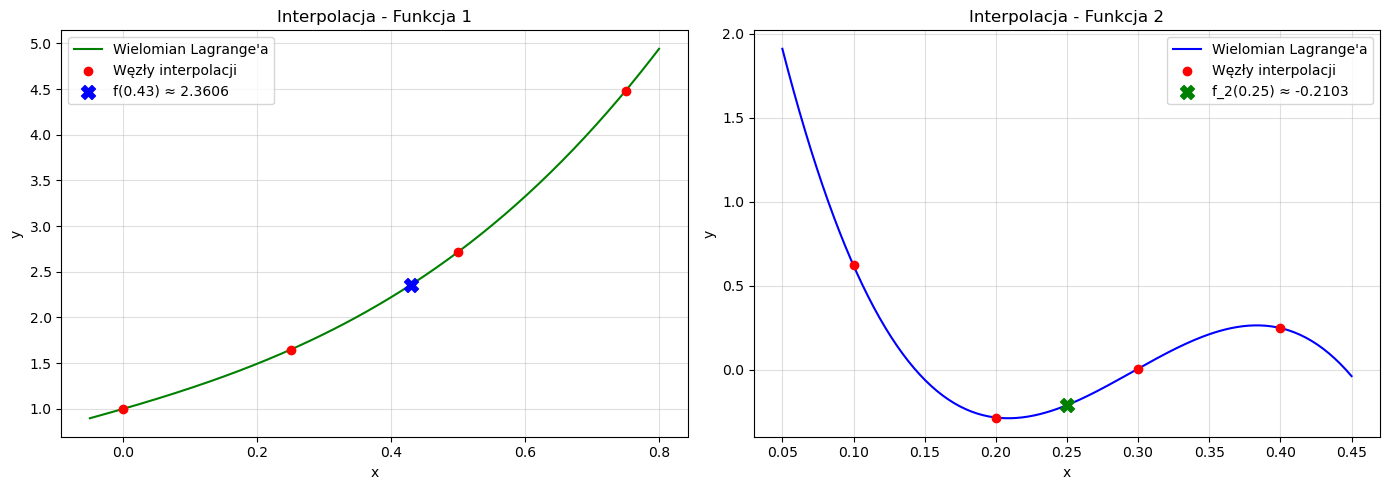

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

# --- FUNKCJA 1 ---
# Dane wejściowe (węzły)
x1 = np.array([0.0, 0.25, 0.5, 0.75])
y1 = np.array([1.0, 1.64872, 2.71828, 4.48169])

# Generowanie wielomianu Lagrange'a
poly1 = lagrange(x1, y1)

# Obliczenie szukanej wartości
x_target1 = 0.43
y_target1 = poly1(x_target1)


# --- FUNKCJA 2 ---
# Dane wejściowe (węzły)
x2 = np.array([0.1, 0.2, 0.3, 0.4])
y2 = np.array([0.62049958, -0.28398668, 0.00660095, 0.24842440])

# Generowanie wielomianu Lagrange'a
poly2 = lagrange(x2, y2)

# Obliczenie szukanej wartości
x_target2 = 0.25
y_target2 = poly2(x_target2)


# --- WYNIKI W KONSOLI ---
print("WYNIKI INTERPOLACJI:")
print(f"Funkcja 1: f({x_target1}) = {y_target1:.5f}")
print(f"Funkcja 2: f_2({x_target2}) = {y_target2:.5f}")


# --- WIZUALIZACJA ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Wykres dla Pierwszej Funkcji
x_dense1 = np.linspace(-0.05, 0.8, 200)
ax1.plot(x_dense1, poly1(x_dense1), 'g-', label='Wielomian Lagrange\'a')
ax1.scatter(x1, y1, color='red', zorder=5, label='Węzły interpolacji')
ax1.scatter(x_target1, y_target1, color='blue', marker='X', s=100, zorder=6, label=f'f({x_target1}) ≈ {y_target1:.4f}')
ax1.set_title("Interpolacja - Funkcja 1")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.grid(True, alpha=0.4)
ax1.legend()

# Wykres dla Drugiej Funkcji
x_dense2 = np.linspace(0.05, 0.45, 200)
ax2.plot(x_dense2, poly2(x_dense2), 'b-', label='Wielomian Lagrange\'a')
ax2.scatter(x2, y2, color='red', zorder=5, label='Węzły interpolacji')
ax2.scatter(x_target2, y_target2, color='green', marker='X', s=100, zorder=6, label=f'f_2({x_target2}) ≈ {y_target2:.4f}')
ax2.set_title("Interpolacja - Funkcja 2")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.grid(True, alpha=0.4)
ax2.legend()

plt.tight_layout()
plt.show()

***Zadanie 3.***

Rozważmy funkcję $f(x)=\frac{1}{25x^2+1}$. 

Przeprowadź interpolacje funkcji $f$ w przedziale $[-2,2]$ wielomianem Lagrange'a oraz funkcjami sklejanymi 3 stopnia w:
- 21 równoodległych węzłach,
- 21 węzłach [Czebyszewa](https://pl.wikipedia.org/wiki/Węzły_Czebyszewa).

**Wskazówka** Interpolację funkcjami sklejanymi możesz przeprowadzić za pomocą funkcji [`interp1d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html#scipy.interpolate.interp1d).

Umieść wielomian interpolacyjny, oryginalną funkcję $f$ oraz węzly interpolacyjne na wspólnym wykresie (jeden wykres dla metody Lagrange'a oraz jeden dla funkcji sklejanych). Porównaj otrzymane rezultaty. Przeprowadź te same działania dla przedziału $x\in[-5,5]$. Jakie problemy możesz zauważyć na otrzymanych wykresach?

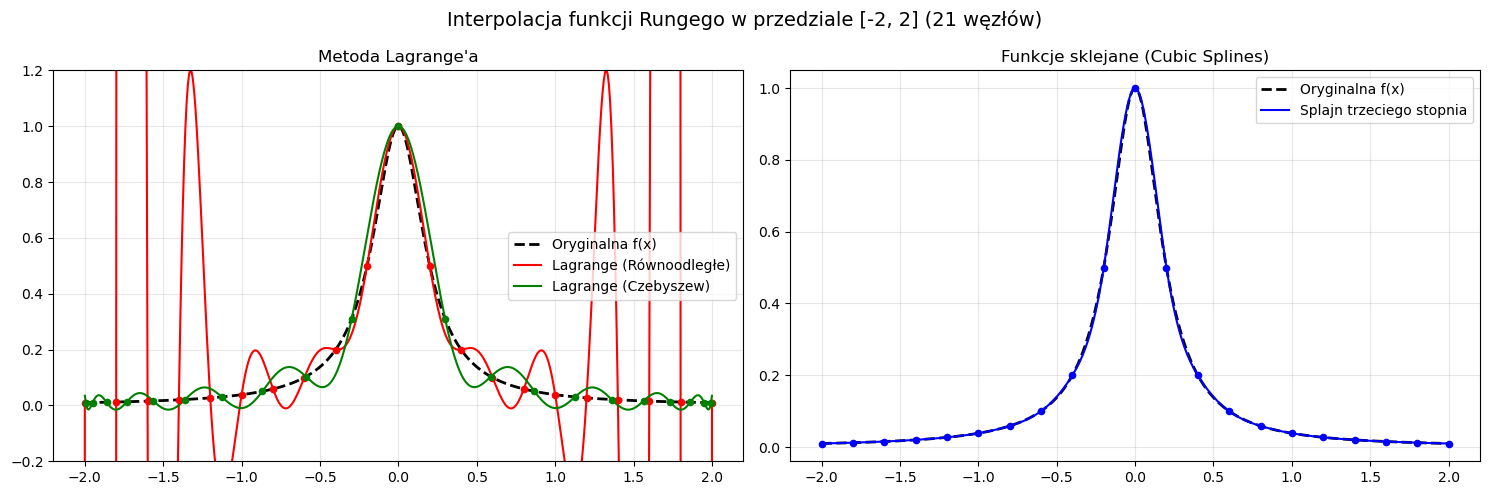

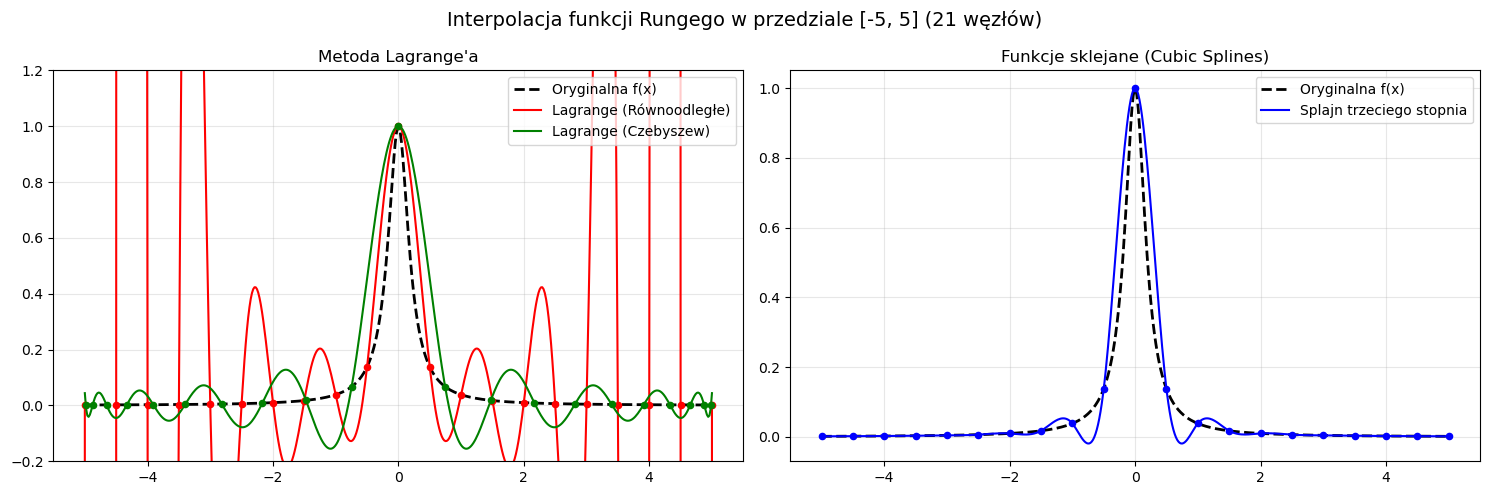

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, interp1d

# Definicja funkcji Rungego
def f_runge(x):
    return 1 / (25 * x**2 + 1)

# Funkcja generująca węzły Czebyszewa w przedziale [a, b]
def chebyshev_nodes(a, b, n):
    i = np.arange(1, n + 1)
    # Klasyczny wzór na węzły w [-1, 1] przeskalowany do [a, b]
    nodes_11 = np.cos((2 * i - 1) * np.pi / (2 * n))
    return 0.5 * (a + b) + 0.5 * (b - a) * nodes_11

def perform_interpolation_plot(a, b, n_nodes, title_suffix):
    # Gęsta siatka do rysowania wykresów oryginalnej funkcji i modeli
    x_dense = np.linspace(a, b, 500)
    y_true = f_runge(x_dense)
    
    # 1. Węzły równoodległe
    x_eq = np.linspace(a, b, n_nodes)
    y_eq = f_runge(x_eq)
    
    # 2. Węzły Czebyszewa
    x_cheb = chebyshev_nodes(a, b, n_nodes)
    y_cheb = f_runge(x_cheb)
    
    # --- INTERPOLACJA LAGRANGE'A ---
    poly_eq = lagrange(x_eq, y_eq)
    poly_cheb = lagrange(x_cheb, y_cheb)
    
    # --- FUNKCJE SKLEJANE (SPLAJNY 3. STOPNIA) ---
    # Dla węzłów równoodległych
    spline_eq = interp1d(x_eq, y_eq, kind='cubic')
    
    # Tworzenie wykresów
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Interpolacja funkcji Rungego w przedziale [{a}, {b}] ({n_nodes} węzłów)", fontsize=14)
    
    # Wykres 1: Metoda Lagrange'a (Równoodległe vs Czebyszew)
    ax1.plot(x_dense, y_true, 'k--', label='Oryginalna f(x)', linewidth=2)
    ax1.plot(x_dense, poly_eq(x_dense), 'r-', label='Lagrange (Równoodległe)')
    ax1.plot(x_dense, poly_cheb(x_dense), 'g-', label='Lagrange (Czebyszew)')
    ax1.scatter(x_eq, y_eq, color='red', s=20, zorder=5)
    ax1.scatter(x_cheb, y_cheb, color='green', s=20, zorder=5)
    ax1.set_ylim(-0.2, 1.2) # Ograniczenie osi Y, by oscylacje nie zepsuły skali
    ax1.set_title("Metoda Lagrange'a")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Wykres 2: Funkcje sklejane 3. stopnia
    ax2.plot(x_dense, y_true, 'k--', label='Oryginalna f(x)', linewidth=2)
    ax2.plot(x_dense, spline_eq(x_dense), 'b-', label='Splajn trzeciego stopnia')
    ax2.scatter(x_eq, y_eq, color='blue', s=20, zorder=5)
    ax2.set_title("Funkcje sklejane (Cubic Splines)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()

# Uruchomienie eksperymentu dla obu przedziałów (21 węzłów)
perform_interpolation_plot(-2, 2, 21, "[-2, 2]")
perform_interpolation_plot(-5, 5, 21, "[-5, 5]")
plt.show()

***Zadanie 4.***

Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

**Zadanie dla zainteresowanych programowaniem funkcyjnym w Pythonie**

Stwórz funkcję znajdującą wielomian interpolacyjny metodą Lagrange'a. Funkcja powinna przyjmować dwie listy:
* listę argumentów ($x$-ów)
* listę wartości ($y$-ów).  


Po wykonaniu obliczeń funkcja powinna zwracać wielomian w postaci obiektu typu **funkcja** (a nie `numpy.Polynomial`).

**Wskazówka** Wykorzystaj wyrażenia *lambda*. Dla ułatwienia możesz się też posłużyć pakietami `operator` i `functools`.
